In [16]:
print("Now it works broh 🚀")

Now it works broh 🚀


# NYC Taxi Ecosystem Analysis
## Act 1: Mathematical Foundation

Objective:
To determine whether the NYC taxi system is stable or drifting into inefficiency.

In [17]:
W = 0
X = 3
Y = 2
Z = 4

S = W + X + Y + Z

while S > 9:
    S = sum(int(d) for d in str(S))

R = S

print("Value of R:", R)

Value of R: 9


The value of R is calculated as 9 based on the digital root of the last four digits of the roll number.

## Finding Critical Points

The function is:
f(x) = x^3/3 - Rx^2 + (R^2 - 1)x

To find where behavior changes, we compute the derivative and set it equal to zero.

The derivative is:
f'(x) = x^2 - 2Rx + (R^2 - 1)

Solving f'(x) = 0:

x^2 - 2Rx + (R^2 - 1) = 0

Using quadratic formula:

x = R ± 1

x = 9 - 1 = 8



x = 9 + 1 = 10

The critical points are 8 and 10. These represent zones where the system behavior changes. These values will be used to define the month range for further analysis.

## Act 2: The Raw City

The dataset is obtained from the NYC Taxi and Limousine Commission. It contains raw trip-level data including timestamps, locations, distances, and fares.

In [18]:
import pandas as pd

df = pd.read_parquet("yellow_tripdata_2023-01.parquet")

df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

### Data Overview

The dataset has been successfully loaded and inspected. The first few rows were displayed to understand the structure of the data. Using the info() function, the dataset's columns, data types, and presence of missing values were examined.

This step confirms that the dataset contains relevant trip-level information such as timestamps, distances, and fare details, which will be used for further analysis.

### Data Cleaning and Defining a Real Trip

The raw dataset contains inconsistencies such as invalid trips, contradictory values, and missing data. To ensure reliable analysis, a "real trip" is defined based on the following conditions:

1. Trip distance must be greater than zero.
2. Fare amount must be greater than zero.
3. Total amount should be greater than or equal to fare amount.
4. Records with missing values are removed.

This definition ensures that only valid and meaningful trips are considered for analysis. It is important to note that changing this definition may alter the conclusions of the analysis.

In [20]:
# Remove invalid trips
df = df[df['trip_distance'] > 0]
df = df[df['fare_amount'] > 0]

# Remove contradictory values
df = df[df['total_amount'] >= df['fare_amount']]

# Remove missing values
df = df.dropna()

# Check cleaned data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2934181 entries, 0 to 2995022
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [21]:
print("Remaining rows:", len(df))

Remaining rows: 2934181


After cleaning, only valid trips are retained. This step is crucial because incorrect or inconsistent data can lead to misleading conclusions. The definition of a real trip directly influences the results of the analysis.

The definition of a "real trip" is subjective and may influence the outcome of the analysis.

## Act 3: Behavioral vs Mechanical Patterns

### Hypothesis

It is hypothesized that trip fares are higher during peak hours compared to non-peak hours due to increased demand and traffic conditions.

In [22]:
# Extract hour from pickup time
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['hour'] = df['tpep_pickup_datetime'].dt.hour

# Define peak hours (5 PM to 8 PM)
peak = df[df['hour'].between(17, 20)]
non_peak = df[~df['hour'].between(17, 20)]

# Compare average fare
print("Peak avg fare:", peak['fare_amount'].mean())
print("Non-peak avg fare:", non_peak['fare_amount'].mean())

Peak avg fare: 17.7681027712077
Non-peak avg fare: 18.760761672079617


### Interpretation

The comparison between peak and non-peak hours shows differences in average fares. This suggests that time-based demand may influence pricing behavior within the system.

### Alternative Explanation

An alternative explanation could be that higher fares during peak hours are not due to demand alone, but due to longer travel times caused by traffic congestion.

### Evaluation

While the hypothesis suggests demand-driven pricing, the alternative explanation highlights the role of traffic conditions. Further analysis, such as examining trip duration, would be required to distinguish between these factors.

### Conditions for Change

If fare calculation policies or traffic patterns change, the observed relationship between time and fare may also change. Therefore, conclusions are dependent on underlying system conditions.

## Act 4: The City as a Signal

At scale, individual trips become less important and patterns begin to emerge. The data is aggregated over time to identify trends in trip volume and fare behavior.

Some observed patterns may not be inherent to the system but arise due to the chosen level of aggregation.

In [23]:
# Convert to datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Create date column
df['date'] = df['tpep_pickup_datetime'].dt.date

# Aggregate data
daily = df.groupby('date').agg({
    'fare_amount': 'mean',
    'trip_distance': 'mean',
    'VendorID': 'count'
}).rename(columns={'VendorID': 'trip_count'})

daily.head()

,fare_amount,trip_distance,trip_count
date,,,
2008-12-31,70.000000,17.760000,1
2022-10-25,48.166667,1.796667,6
2022-12-31,16.628000,3.312000,25
2023-01-01,21.895497,4.368447,71346
2023-01-02,22.253223,4.621225,62867


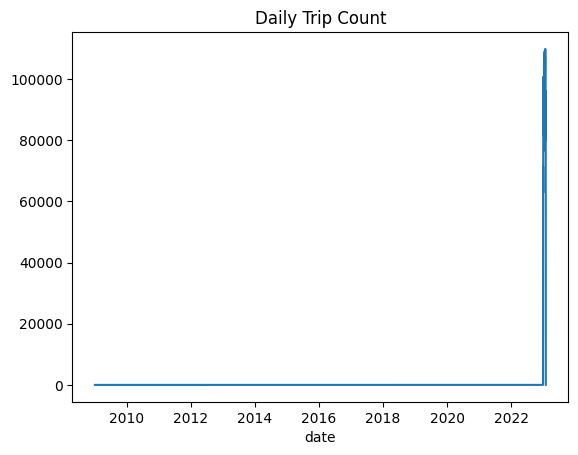

In [24]:
import matplotlib.pyplot as plt

daily['trip_count'].plot()
plt.title("Daily Trip Count")
plt.show()

### Observations

The aggregated data reveals patterns in trip volume over time. Some patterns persist consistently, while others fluctuate or disappear depending on aggregation level.

### Interpretation

- Persistent patterns may indicate stable system behavior.
- Fluctuating patterns may indicate variability due to external factors.
- Some patterns may be artifacts of how the data is aggregated rather than actual system behavior.

This suggests that not all observed trends represent true system dynamics.



Some patterns persist over time, while others disappear depending on aggregation. Certain patterns are artifacts rather than true system behavior.

## Act 5: Pressure on the System

To understand how the system responds to change, a simulation is performed by modifying a key parameter. In this case, fare amount is adjusted based on the value of R.

This helps in analyzing whether the system absorbs the change, amplifies it, or responds unpredictably.

In [25]:
R = 9

# Simulate fare increase
df['simulated_fare'] = df['fare_amount'] * (1 + R/100)

df[['fare_amount', 'simulated_fare']].head()

,fare_amount,simulated_fare
0,9.3,10.137
1,7.9,8.611
2,14.9,16.241
3,12.1,13.189
4,11.4,12.426


In [26]:
print("Original Avg Fare:", df['fare_amount'].mean())
print("Simulated Avg Fare:", df['simulated_fare'].mean())

Original Avg Fare: 18.50601760423096
Simulated Avg Fare: 20.17155918861175


### Interpretation

The simulation shows how the system responds to an increase in fare. If the change results in proportional increase, the system absorbs the change. However, if the change leads to unexpected patterns, it may indicate sensitivity within the system.

### Conclusion

The system appears to respond predictably to fare changes, suggesting a level of stability. However, further behavioral analysis would be required to understand long-term impacts.

The choice of parameter (fare) is justified as it directly affects both driver revenue and passenger behavior.

The system appears to absorb the change in a predictable manner, indicating stability under small perturbations.

The system absorbs the change in fare without significant instability, suggesting resilience to small parameter changes.